# Iniciando con el proyecto

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('./data/titanic_clean.csv')


In [5]:
df.sample(4)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
128,1,3,female,28.0,1,1,22.3583,C
580,1,2,female,25.0,1,1,30.0000,S
615,1,2,female,24.0,1,2,65.0000,S
745,0,1,male,70.0,1,1,71.0000,S


In [3]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

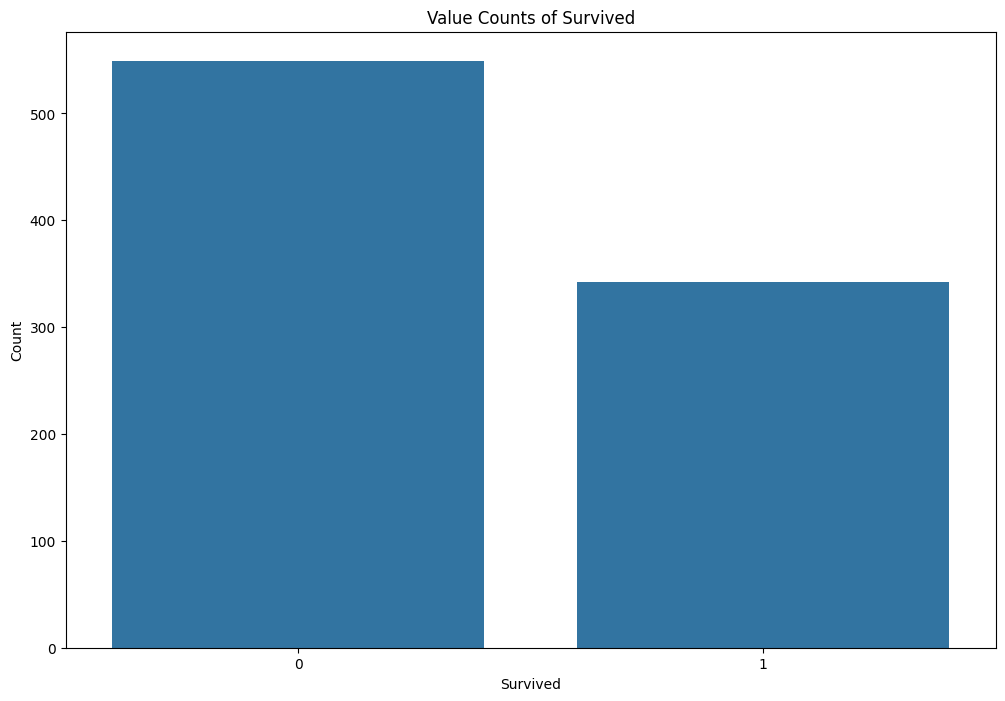

In [4]:
plt.figure(figsize=(12, 8))

sns.barplot(x = df['Survived'].value_counts().index, y = df['Survived'].value_counts())
plt.title('Value Counts of Survived')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

# Generando la graficas reales

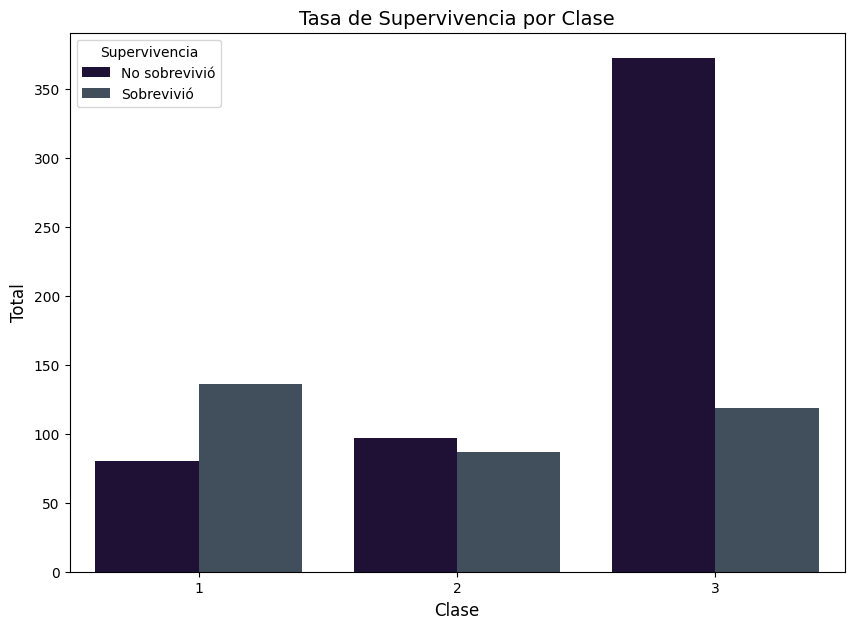

In [5]:
# Configurar el tamaño de la figura
plt.figure(figsize=(10, 7))

# Crear la gráfica de barras proporcionales
# x='Pclass' para las clases del Titanic
# hue='Survived' para separar por sobrevivientes
# palette permite usar los colores oscuros y elegantes de tu imagen
ax = sns.countplot(data=df, x='Pclass', hue='Survived', palette=['#1e0b3c', '#3d4e5f'])

# Configurar títulos y etiquetas
plt.title('Tasa de Supervivencia por Clase', fontsize=14)
plt.xlabel('Clase', fontsize=12)
plt.ylabel('Total', fontsize=12)

# Personalizar la leyenda para que diga "No sobrevivió" y "Sobrevivió"
legend = ax.get_legend()
legend.set_title('Supervivencia')
new_labels = ['No sobrevivió', 'Sobrevivió']
for t, l in zip(legend.texts, new_labels):
    t.set_text(l)

# Mostrar la gráfica
plt.show()


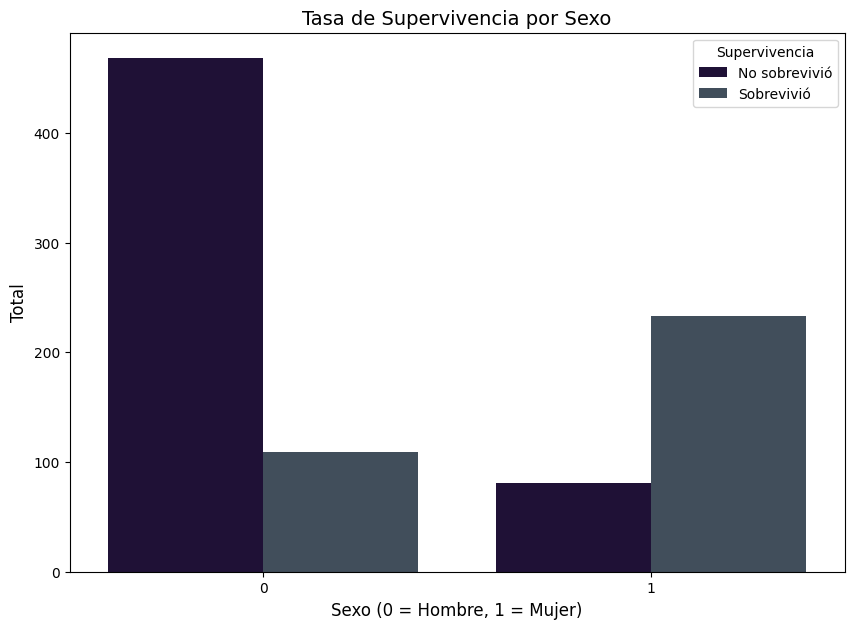

In [12]:
# 1. Crear la columna codificada (0 = hombres, 1 = mujeres)
df['Sex_encoded'] = df['Sex'].map({'male': 0, 'female': 1})

# 2. Configurar el tamaño de la figura
plt.figure(figsize=(10, 7))

# 3. Crear la gráfica
# x='Sex_encoded' para mostrar 0 y 1 en el eje horizontal
# hue='Survived' para separar por quienes sobrevivieron o no
ax = sns.countplot(data=df, x='Sex_encoded', hue='Survived', palette=['#1e0b3c', '#3d4e5f'])

# 4. Configurar títulos y etiquetas
plt.title('Tasa de Supervivencia por Sexo', fontsize=14)
plt.xlabel('Sexo (0 = Hombre, 1 = Mujer)', fontsize=12)
plt.ylabel('Total', fontsize=12)

# 5. Personalizar la leyenda
legend = ax.get_legend()
legend.set_title('Supervivencia')
new_labels = ['No sobrevivió', 'Sobrevivió']
for t, l in zip(legend.texts, new_labels):
    t.set_text(l)

plt.show()


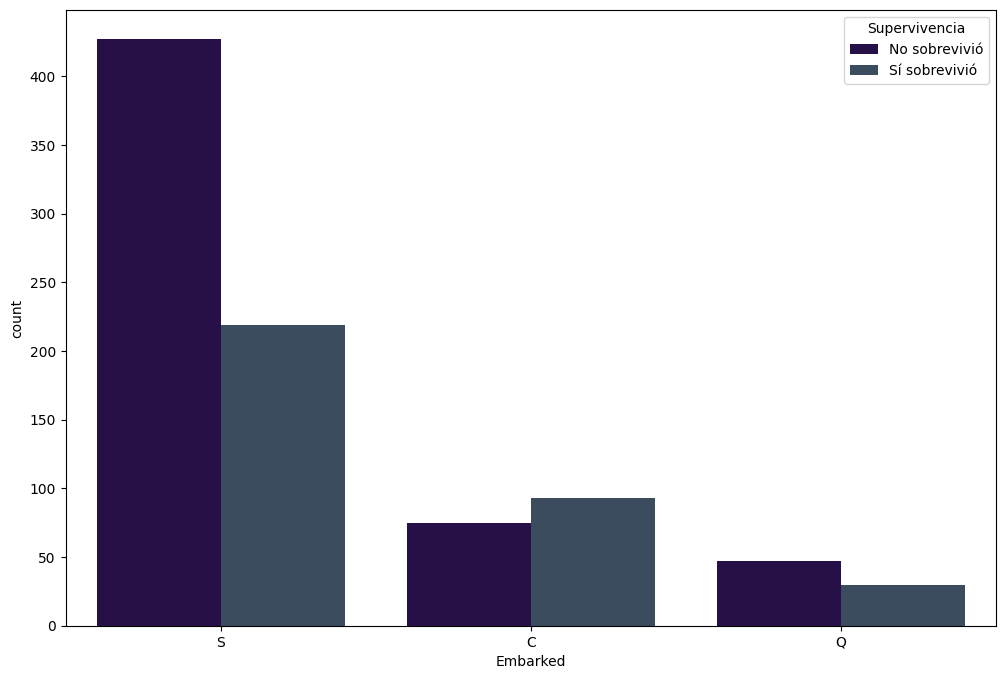

In [13]:
plt.figure(figsize = (12, 8))

# colores para cada una de las clases
color = ['#240750', '#344C64']

sns.countplot(df, x = 'Embarked', hue = 'Survived', palette=color) 
plt.legend(title = 'Supervivencia', labels = ['No sobrevivió', 'Sí sobrevivió'])
plt.show()

# Calcular Datos y Distribucion


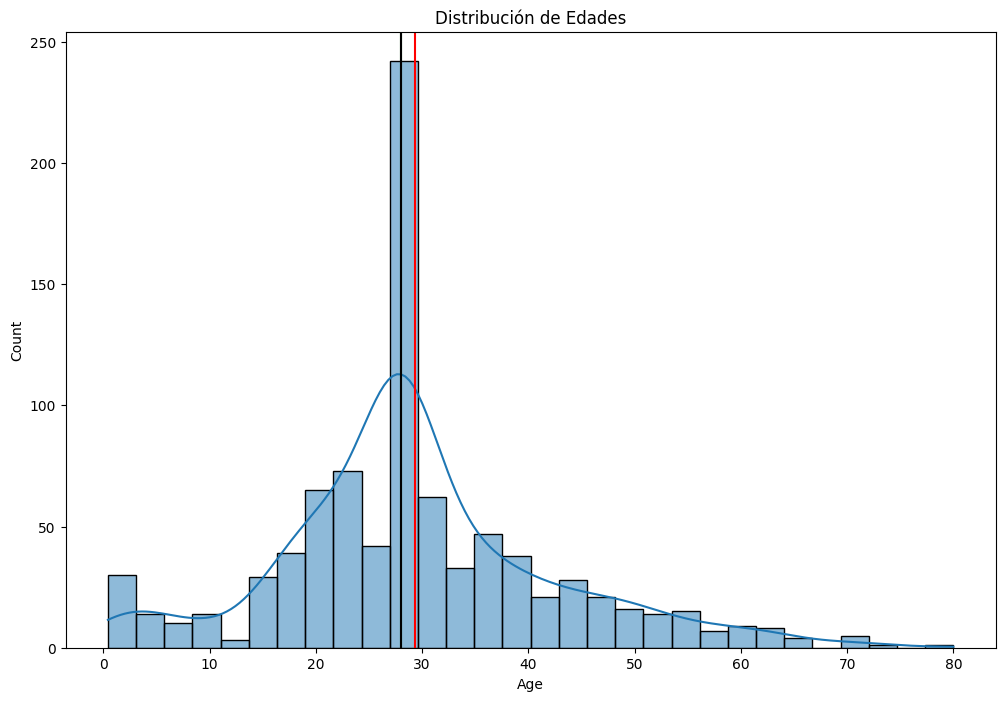

Media: 29.36158249158249
Mediana: 28.0
Moda: 28.0


In [14]:
plt.figure(figsize = (12, 8))

sns.histplot(df, x = 'Age', kde = True)
plt.title('Distribución de Edades')
plt.axvline(df['Age'].mean(), color = 'red')
plt.axvline(df['Age'].median(), color = 'green')
plt.axvline(df['Age'].mode()[0], color = 'black')
plt.show()

# Print the results
print(f"Media: {df['Age'].mean()}")
print(f"Mediana: {df['Age'].median()}")
print(f"Moda: {df['Age'].mode()[0]}")

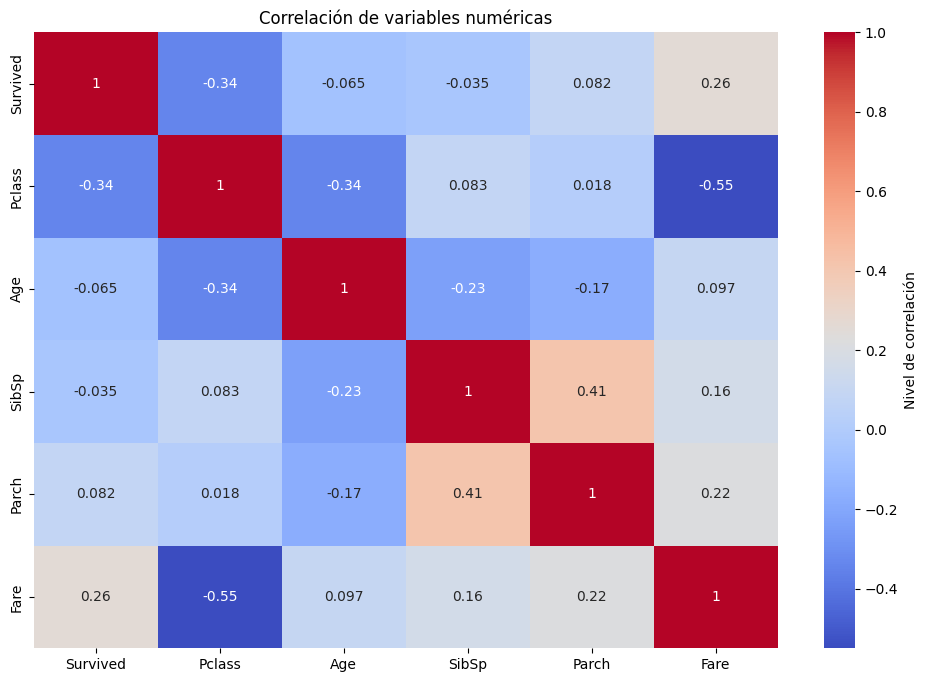

In [15]:
plt.figure(figsize = (12, 8))
sns.heatmap(df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr(), 
            annot=True, 
            cbar=True,  # Activar la barra de colores
            cmap='coolwarm',  # Cambiar la paleta de colores
            cbar_kws={'label': 'Nivel de correlación'})  # Etiqueta para la barra de colores
plt.title('Correlación de variables numéricas')
plt.show()

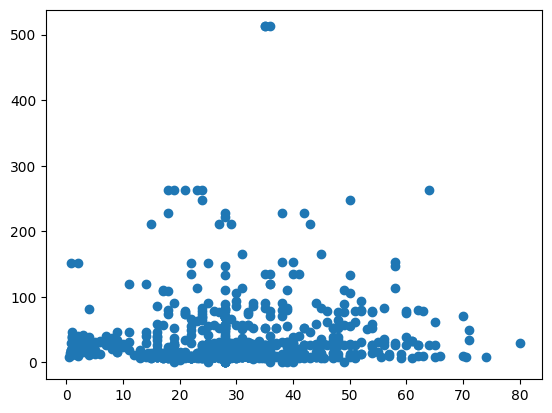

In [19]:
plt.scatter(df[['Age']], df[['Fare']])
plt. show()

# Ejercicios

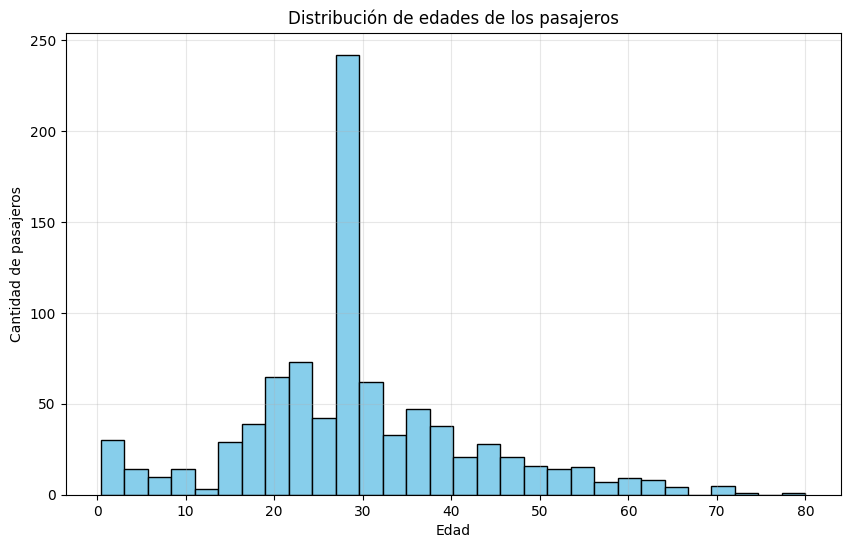

In [6]:
# Ejercicio 1: Distribución de edades de los pasajeros
plt.figure(figsize=(10, 6))
plt.hist(df['Age'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Edad')
plt.ylabel('Cantidad de pasajeros')
plt.title('Distribución de edades de los pasajeros')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Ejercicio 2: Cantidad de sobrevivientes por clase de pasajero
plt.figure(figsize=(10, 6))
survival_by_class = df.groupby('Pclass')['Survived'].sum()
survival_by_class.plot(kind='bar', color='coral', edgecolor='black')
plt.xlabel('Clase de pasajero')
plt.ylabel('Cantidad de sobrevivientes')
plt.title('Cantidad de sobrevivientes por clase de pasajero')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

In [ ]:
# Ejercicio 3: Cantidad de sobrevivientes por género
plt.figure(figsize=(10, 6))
survival_by_sex = df.groupby('Sex')['Survived'].sum()
survival_by_sex.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.xlabel('Género')
plt.ylabel('Cantidad de sobrevivientes')
plt.title('Cantidad de sobrevivientes por género')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

In [ ]:
# Ejercicio 4: Cantidad de sobrevivientes por puerto de embarque
plt.figure(figsize=(10, 6))
survival_by_embarked = df.groupby('Embarked')['Survived'].sum()
survival_by_embarked.plot(kind='bar', color='lightyellow', edgecolor='black')
plt.xlabel('Puerto de embarque')
plt.ylabel('Cantidad de sobrevivientes')
plt.title('Cantidad de sobrevivientes por puerto de embarque')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

In [ ]:
# Ejercicio 5: Tasa de supervivencia por grupo de edad
def categorizar_edad(age):
    if pd.isna(age):
        return 'Desconocido'
    elif age < 3:
        return 'Infante'
    elif age < 13:
        return 'Niño'
    elif age < 18:
        return 'Adolescente'
    elif age < 35:
        return 'Joven Adulto'
    elif age < 60:
        return 'Adulto'
    else:
        return 'Mayor'

df['Grupo_Edad'] = df['Age'].apply(categorizar_edad)
survival_by_age_group = df.groupby('Grupo_Edad')['Survived'].mean() * 100

plt.figure(figsize=(10, 6))
survival_by_age_group.plot(kind='bar', color='lightcyan', edgecolor='black')
plt.xlabel('Grupo de edad')
plt.ylabel('Tasa de supervivencia (%)')
plt.title('Tasa de supervivencia por grupo de edad')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

In [ ]:
# Ejercicio 6: Conteo de pasajeros en cada clase
plt.figure(figsize=(10, 6))
passenger_count_by_class = df['Pclass'].value_counts().sort_index()
passenger_count_by_class.plot(kind='bar', color='plum', edgecolor='black')
plt.xlabel('Clase de pasajero')
plt.ylabel('Cantidad de pasajeros')
plt.title('Conteo de pasajeros en cada clase')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

In [ ]:
# Ejercicio 7: Distribución de género dentro de cada clase de pasajero
plt.figure(figsize=(12, 6))
gender_by_class = pd.crosstab(df['Pclass'], df['Sex'])
gender_by_class.plot(kind='bar', color=['lightpink', 'lightblue'], edgecolor='black')
plt.xlabel('Clase de pasajero')
plt.ylabel('Cantidad de pasajeros')
plt.title('Distribución de género dentro de cada clase de pasajero')
plt.xticks(rotation=0)
plt.legend(title='Género')
plt.grid(True, alpha=0.3, axis='y')
plt.show()

In [ ]:
# Ejercicio 8: Distribución de clase de pasajero por puerto de embarque
plt.figure(figsize=(12, 6))
class_by_embarked = pd.crosstab(df['Embarked'], df['Pclass'])
class_by_embarked.plot(kind='bar', color=['salmon', 'gold', 'lightseagreen'], edgecolor='black')
plt.xlabel('Puerto de embarque')
plt.ylabel('Cantidad de pasajeros')
plt.title('Distribución de clase de pasajero por puerto de embarque')
plt.xticks(rotation=45)
plt.legend(title='Clase')
plt.grid(True, alpha=0.3, axis='y')
plt.show()

In [ ]:
# Ejercicio 9: Conteo de pasajeros por género
plt.figure(figsize=(10, 6))
passenger_count_by_sex = df['Sex'].value_counts()
passenger_count_by_sex.plot(kind='bar', color=['lightcoral', 'lightskyblue'], edgecolor='black')
plt.xlabel('Género')
plt.ylabel('Cantidad de pasajeros')
plt.title('Conteo de pasajeros por género')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

In [ ]:
# Ejercicio 10: Valores máximo y mínimo de la columna de edad
edad_max = df['Age'].max()
edad_min = df['Age'].min()

print(f"Edad máxima: {edad_max}")
print(f"Edad mínima: {edad_min}")

In [ ]:
# Ejercicio 11: Distribución de edades con líneas de media, mediana y moda
from scipy import stats

edad_mean = df['Age'].mean()
edad_median = df['Age'].median()
edad_mode = df['Age'].mode()[0]

plt.figure(figsize=(12, 6))
plt.hist(df['Age'].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(edad_mean, color='red', linestyle='--', linewidth=2, label=f'Media: {edad_mean:.2f}')
plt.axvline(edad_median, color='green', linestyle='--', linewidth=2, label=f'Mediana: {edad_median:.2f}')
plt.axvline(edad_mode, color='orange', linestyle='--', linewidth=2, label=f'Moda: {edad_mode:.2f}')
plt.xlabel('Edad')
plt.ylabel('Cantidad de pasajeros')
plt.title('Distribución de edades con media, mediana y moda')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Ejercicio 12: Diagrama de caja (boxplot) de la columna de edad
plt.figure(figsize=(10, 6))
plt.boxplot(df['Age'].dropna(), vert=True)
plt.ylabel('Edad')
plt.title('Diagrama de caja - Edad (mostrando outliers)')
plt.grid(True, alpha=0.3, axis='y')
plt.show()

In [ ]:
# Ejercicio 13: Valores máximo y mínimo de la columna de tarifa (Fare)
fare_max = df['Fare'].max()
fare_min = df['Fare'].min()

print(f"Tarifa máxima: {fare_max}")
print(f"Tarifa mínima: {fare_min}")

In [ ]:
# Ejercicio 14: Distribución de tarifas con líneas de media, mediana y moda
fare_mean = df['Fare'].mean()
fare_median = df['Fare'].median()
fare_mode = df['Fare'].mode()[0]

plt.figure(figsize=(12, 6))
plt.hist(df['Fare'].dropna(), bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
plt.axvline(fare_mean, color='red', linestyle='--', linewidth=2, label=f'Media: {fare_mean:.2f}')
plt.axvline(fare_median, color='green', linestyle='--', linewidth=2, label=f'Mediana: {fare_median:.2f}')
plt.axvline(fare_mode, color='orange', linestyle='--', linewidth=2, label=f'Moda: {fare_mode:.2f}')
plt.xlabel('Tarifa')
plt.ylabel('Cantidad de pasajeros')
plt.title('Distribución de tarifas con media, mediana y moda')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Ejercicio 15: Diagrama de caja (boxplot) de la columna de tarifa (Fare)
plt.figure(figsize=(10, 6))
plt.boxplot(df['Fare'].dropna(), vert=True)
plt.ylabel('Tarifa')
plt.title('Diagrama de caja - Tarifa (mostrando outliers)')
plt.grid(True, alpha=0.3, axis='y')
plt.show()

In [ ]:
# Ejercicio 16: Pasajeros que pagaron 0 en tarifa
zero_fare_passengers = df[df['Fare'] == 0]
print(f"Cantidad de pasajeros con tarifa 0: {len(zero_fare_passengers)}")
print("\nDatos de pasajeros con tarifa 0:")
print(zero_fare_passengers)

In [ ]:
# Ejercicio 17: Conteo de pasajeros por número de hermanos/esposos a bordo (SibSp)
plt.figure(figsize=(10, 6))
sibsp_count = df['SibSp'].value_counts().sort_index()
sibsp_count.plot(kind='bar', color='khaki', edgecolor='black')
plt.xlabel('Número de hermanos/esposos a bordo (SibSp)')
plt.ylabel('Cantidad de pasajeros')
plt.title('Conteo de pasajeros por número de hermanos/esposos a bordo')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

In [ ]:
# Ejercicio 18: Tasa de supervivencia basada en el número de hermanos/esposos a bordo (SibSp)
plt.figure(figsize=(10, 6))
survival_by_sibsp = df.groupby('SibSp')['Survived'].mean() * 100
survival_by_sibsp.plot(kind='bar', color='lightsteelblue', edgecolor='black')
plt.xlabel('Número de hermanos/esposos a bordo (SibSp)')
plt.ylabel('Tasa de supervivencia (%)')
plt.title('Tasa de supervivencia por número de hermanos/esposos a bordo')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

In [ ]:
# Ejercicio 19: Porcentaje de supervivencia para cada valor de SibSp
sibsp_survival_percentage = (df.groupby('SibSp')['Survived'].sum() / df['SibSp'].value_counts()) * 100
sibsp_survival_percentage = sibsp_survival_percentage.sort_index()

print("Porcentaje de supervivencia por número de hermanos/esposos a bordo (SibSp):")
for sibsp, percentage in sibsp_survival_percentage.items():
    print(f"SibSp = {sibsp}: {percentage:.2f}%")

In [ ]:
# Ejercicio 20: Mapa de calor de la matriz de correlación
plt.figure(figsize=(10, 8))
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numeric_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de correlación de características numéricas')
plt.tight_layout()
plt.show()